In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/tempering-data-for-carbon-and-low-alloy-steels/Tempering data for carbon and low alloy steels - Raiipa.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

df = pd.read_csv("/kaggle/input/tempering-data-for-carbon-and-low-alloy-steels/Tempering data for carbon and low alloy steels - Raiipa.csv")

In [3]:
df.head(3) #raw data

,Source,Steel type,Initial hardness (HRC) - post quenching,Tempering time (s),Tempering temperature (ºC),C (%wt),Mn (%wt),P (%wt),S (%wt),Si (%wt),Ni (%wt),Cr (%wt),Mo (%wt),V (%wt),Al (%wt),Cu (%wt),Final hardness (HRC) - post tempering
0,"Grange and Baughman, 1956",AISI-SAE 1026,?,600,204.4,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,50.6
1,"Grange and Baughman, 1956",AISI-SAE 1026,?,600,260.0,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,48.3
2,"Grange and Baughman, 1956",AISI-SAE 1026,?,600,315.6,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,43.7


In [4]:
df = df.drop(["Source", "Steel type", "Initial hardness (HRC) - post quenching"], axis = "columns")

In [5]:
df.head(3)

,Tempering time (s),Tempering temperature (ºC),C (%wt),Mn (%wt),P (%wt),S (%wt),Si (%wt),Ni (%wt),Cr (%wt),Mo (%wt),V (%wt),Al (%wt),Cu (%wt),Final hardness (HRC) - post tempering
0,600,204.4,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,50.6
1,600,260.0,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,48.3
2,600,315.6,0.25,0.79,0.012,0.026,0.11,0.0,0.0,0.0,0.0,0.0,0.0,43.7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1466 entries, 0 to 1465
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tempering time (s)                     1466 non-null   int64  
 1   Tempering temperature (ºC)             1466 non-null   float64
 2   C (%wt)                                1466 non-null   float64
 3   Mn (%wt)                               1466 non-null   float64
 4   P (%wt)                                1466 non-null   float64
 5   S (%wt)                                1466 non-null   float64
 6   Si (%wt)                               1466 non-null   float64
 7   Ni (%wt)                               1466 non-null   float64
 8   Cr (%wt)                               1466 non-null   float64
 9   Mo (%wt)                               1466 non-null   float64
 10  V (%wt)                                1466 non-null   float64
 11  Al (

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [8]:
x = df.drop(['Final hardness (HRC) - post tempering'], axis = "columns")
y = df["Final hardness (HRC) - post tempering"]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state = 42, test_size = 0.2)

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(xtrain, ytrain)

LinearRegression()

In [10]:
lr.score(xtest, ytest)

0.8555464962758786

With Scaling

In [11]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)
xtrain_scaled

array([[-0.60676609,  1.30258491, -0.63036308, ..., -0.19279041,
        -0.15928537, -0.31055367],
       [-0.63089793,  1.59259251,  2.89411834, ..., -0.19279041,
        -0.15928537, -0.31055367],
       [-0.52632663,  0.98703848, -0.13332083, ..., -0.19279041,
        -0.15928537, -0.31055367],
       ...,
       [ 2.7985046 ,  0.04153425, -0.67554874, ..., -0.19279041,
        -0.15928537, -0.31055367],
       [ 1.94048364, -1.24505523,  2.89411834, ..., -0.19279041,
        -0.15928537, -0.31055367],
       [-0.60676609, -0.96129046,  2.30670477, ..., -0.19279041,
        -0.15928537, -0.31055367]])

<Axes: >

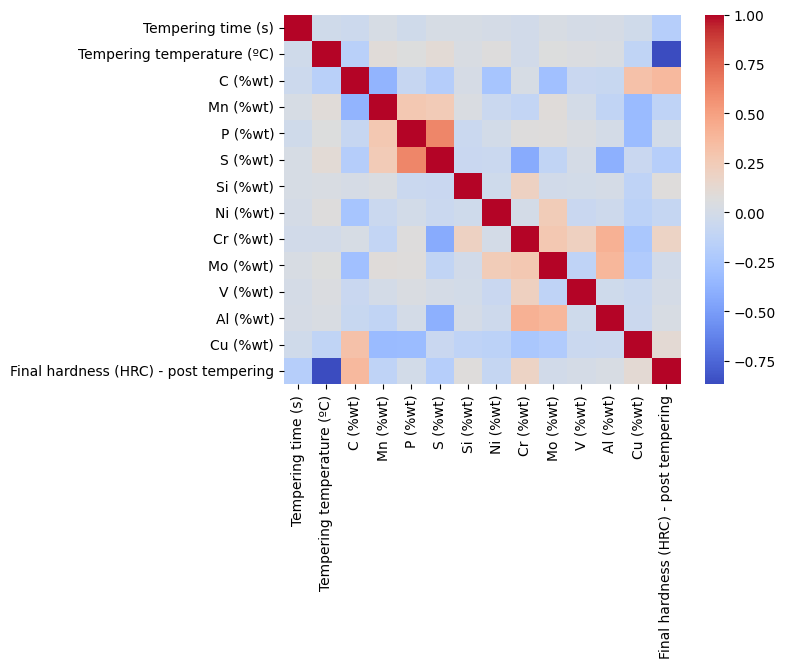

In [12]:
import seaborn as sns
sns.heatmap(df.corr(), cmap = 'coolwarm')

Checking RandomForest, SVR and LinearRegression With Pipeline Scaling

In [13]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth = 10) #max depth was kept as 10 to prevent overfitting.

rfr.fit(xtrain,ytrain)


RandomForestRegressor(max_depth=10)

In [14]:
rfr.score(xtest,ytest)

0.9720343493307484

In [15]:
score_rfr = cross_val_score(rfr, x, y, cv = 5)
print("Cross-Val Score Of Random Forest=", score_rfr.mean())

Cross-Val Score Of Random Forest= 0.8984853976300613


Pipe Line For SVR With Scaling

In [16]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])

scores = cross_val_score(pipe, x, y, cv = 5)
print("Cross Val Score Of SVR is",scores.mean())

Cross Val Score Of SVR is 0.6515621846383186


Piple Line For LR With Scaling

In [17]:
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

scores = cross_val_score(pipe2, x, y, cv = 5)
print("Cross Val Score Of LR is",scores.mean())

Cross Val Score Of LR is 0.8059789818791703


Analysis Of Model

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = rfr.predict(xtest)

print("MAE:", mean_absolute_error(ytest, pred))
print("RMSE:", np.sqrt(mean_squared_error(ytest, pred)))

MAE: 1.565112586911123
RMSE: 2.4185389247046882


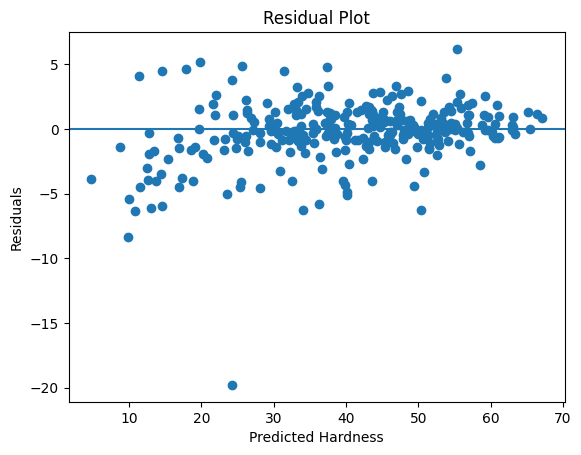

In [19]:
residuals = ytest - pred

plt.scatter(pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Hardness")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [20]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


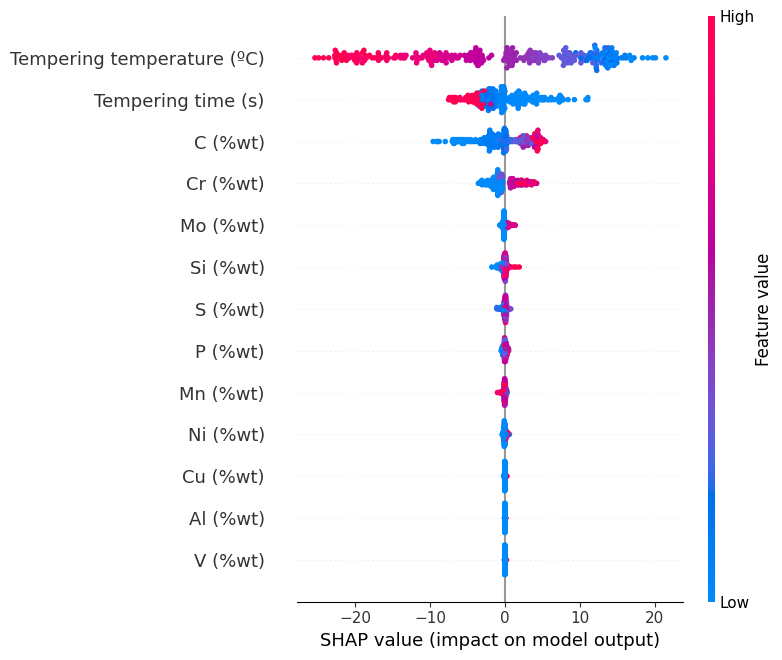

In [21]:
import shap

explainer = shap.TreeExplainer(rfr)

shap.summary_plot(explainer.shap_values(xtest), xtest)

We will now be using Optuna for best hyper parameters

In [22]:
import optuna

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    optunamodel = RandomForestRegressor(
       n_estimators = n_estimators,
        max_depth = max_depth,
        random_state = 42
    )

    score = cross_val_score(optunamodel, xtrain, ytrain, cv=3, scoring = 'r2').mean()

    return score

In [23]:
study = optuna.create_study(direction = 'maximize', sampler = optuna.samplers.TPESampler())
study.optimize(objective, n_trials = 50)

[I 2026-03-13 16:37:58,692] A new study created in memory with name: no-name-34f594e6-396b-4b13-9821-9ff86bcb1856
[I 2026-03-13 16:38:00,943] Trial 0 finished with value: 0.9749539046588218 and parameters: {'n_estimators': 157, 'max_depth': 12}. Best is trial 0 with value: 0.9749539046588218.
[I 2026-03-13 16:38:02,842] Trial 1 finished with value: 0.9746384206651166 and parameters: {'n_estimators': 128, 'max_depth': 16}. Best is trial 0 with value: 0.9749539046588218.
[I 2026-03-13 16:38:03,348] Trial 2 finished with value: 0.8483669890309152 and parameters: {'n_estimators': 83, 'max_depth': 3}. Best is trial 0 with value: 0.9749539046588218.
[I 2026-03-13 16:38:04,996] Trial 3 finished with value: 0.9749213345289206 and parameters: {'n_estimators': 114, 'max_depth': 17}. Best is trial 0 with value: 0.9749539046588218.
[I 2026-03-13 16:38:07,384] Trial 4 finished with value: 0.9752352023548939 and parameters: {'n_estimators': 166, 'max_depth': 14}. Best is trial 4 with value: 0.975235

In [24]:
study.best_trial.value

0.9752352023548939

In [25]:
study.best_trial.params

{'n_estimators': 166, 'max_depth': 14}

In [26]:
from sklearn.metrics import r2_score

In [27]:
best_model = RandomForestRegressor(
    **study.best_params,
    random_state=42
)

scores = cross_val_score(best_model, xtrain, ytrain, cv=5, scoring='r2')

print(f"Individual fold scores: {scores}")
print(f"Mean R²: {scores.mean():.4f}")
print(f"Std R²: {scores.std():.4f}")

Individual fold scores: [0.97961635 0.97863355 0.97845663 0.97941686 0.97141215]
Mean R²: 0.9775
Std R²: 0.0031


In [28]:
best_model.fit(xtrain, ytrain)
test_score = best_model.score(xtest, ytest)
print(f"Test R²: {test_score:.4f}")

Test R²: 0.9745
